**Core Components**

- StateGraph and how state, Nodes and Edges work together for more complex scenarios.

*State*

- First step in defining a stateGraph is to define its state.

- State schema works as input for all nodes and edges.

- Defined using TypedDict

- Each node will read and potentially update this graph_state

In [3]:
#!/usr/bin/python3
from typing import TypedDict


class State(TypedDict):
    #we have one key to hold our string state
    graph_state:str

*Nodes*

- Represents any acton or function. 

- In StateGraph, nodes receive the entire current state as their first positional argument

- Their return value is used to update the state.

- By default, if a node returns {'key':value}, it will override the existing "key" in the state.

- Three functions below to be added as nodes

In [10]:
def node_1(state):
    print('--Node1--')
    #Append to the graph_state
    return {'graph_state':state['graph_state']+' I am'}

def node_2(state):
    print('--Node2--')
    return {'graph_state': state['graph_state']+" happy"}

def node_3(state):
    print('--Node3--')
    return {'graph_state':state['graph_state']+ " sad"}

# The above functions receive the state as an argument, append there output and return the updated state


*Edges(and conditional logic)*

- Edges connect nodes. Normal edges simply move sequentially, conditional edges allow your graph to make decisions based on the state or output.

- We have a conditional edge that randomly decides which path to take.

- Nodes update the state. conditional edge functions decide which node to go to nect based on the state


In [11]:
import random
from typing import Literal

# Function to route conditional edge
def mood(state)->Literal['node_2', 'node_3']:
    user_input=state['graph_state']  #Access the current state
    if random.random()>0.5:     #50% of the time will return node2
        return 'call node_2'    # This string matches a key in the conditional edges mapping
    return 'call node_3'


**Graph Construction with StateGraph**

- Involves a few key steps:

1. Initialize StateGraph: Pass your state class to it
2. Add Nodes: Register your functions as nodes.
3. Define Flow with Edges: Connect your nodes using add_edge for direct transitions and "add_conditional_edges" for decision points.
4. Set START and END points
5. Compile your graph

In [12]:
from langgraph.graph import StateGraph, START, END

# Build graph
workflow=StateGraph(State)    # Initialize with our defined state
workflow.add_node('node_1', node_1)
workflow.add_node('node_2', node_2)
workflow.add_node('node_3', node_3)

# Define the flow using edges
workflow.add_edge(START, 'node_1')  # Start at node_1
workflow.add_conditional_edges(
    'node_1',           # From node_1
    mood,               # Use mood function to decide
    {
        'call node_2':'node_2',    # If mood returns 'call node_2' go to node 2
        'call node_3':'node_3'      # If mood returns 'call node_3' go to node 3
    }
)

workflow.add_edge('node_2', END)  
workflow.add_edge('node_3', END)

app=workflow.compile()

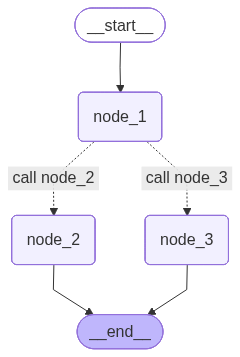

In [13]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

*Graph Invocation*
- The above compiled graph implements the Runnable protocol, meaning you can execute it using methods like invoke()

- When invoke() is called,graph states from the START node. Progresses through the defined nodes. 

- Conditional edges will route execution based on their logic.

- Each node updates the state and returns it.

- Execution continues until the END node.



In [15]:
app.invoke({"graph_state":"Hi, my name is Allan."})
# We have updated the state now execution continues to node_1 which adds 'I am' and finally the conditional edge decides if to run node_2 or node_3(Random)

--Node1--
--Node3--


{'graph_state': 'Hi, my name is Allan. I am sad'}

N/B: invoke() runs the entire graph synchronously, returning the final state once all nodes have executed.